<a href="https://colab.research.google.com/github/Keerthanamurugesan2001/agent_youtube/blob/main/ai_agent_vs_ai_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install langchain langchain-openai langgraph pydantic

# database


In [ ]:
# ==========================================
# DOMINO'S PIZZA - STORE INVENTORY DATABASE
# ==========================================

INVENTORY = {
    # --------------------------------------
    # 1. PIZZAS (Base Sizes & Varieties)
    # --------------------------------------
    "margherita": {
        "category": "Veg Pizza",
        "stock": 45,
        "unit": "pies",
        "price": 9.99,
        "description": "Classic delight with 100% real mozzarella cheese"
    },
    "farmhouse": {
        "category": "Veg Pizza",
        "stock": 30,
        "unit": "pies",
        "price": 13.99,
        "description": "Onion, capsicum, tomato, and grilled mushroom"
    },
    "peppy paneer": {
        "category": "Veg Pizza",
        "stock": 20,
        "unit": "pies",
        "price": 14.49,
        "description": "Juicy paneer, crisp capsicum, and spicy red paprika"
    },
    "pepper barbecue chicken": {
        "category": "Non-Veg Pizza",
        "stock": 25,
        "unit": "pies",
        "price": 15.99,
        "description": "Pepper barbecue chicken for that extra punch"
    },
    "chicken dominator": {
        "category": "Non-Veg Pizza",
        "stock": 15,
        "unit": "pies",
        "price": 18.99,
        "description": "Double pepper barbecue chicken, peri-peri chicken, chicken tikka"
    },
    "pepperoni": {
        "category": "Non-Veg Pizza",
        "stock": 18,
        "unit": "pies",
        "price": 16.49,
        "description": "American classic loaded with pork pepperoni"
    },

    # --------------------------------------
    # 3. TOPPINGS & CUSTOMIZATIONS
    # --------------------------------------
    "extra cheese": {
        "category": "Topping",
        "stock": 100,
        "unit": "portions",
        "price": 1.75,
        "description": "Extra 100% Mozzarella cheese layer"
    },
    "cheese burst": {
        "category": "Crust Upgrade",
        "stock": 35,
        "unit": "upgrades",
        "price": 2.50,
        "description": "Crust filled with liquid cheese"
    },
    "onion": {
        "category": "Topping",
        "stock": 80,
        "unit": "portions",
        "price": 0.99,
        "description": "Fresh crunchy red onions"
    },

    # --------------------------------------
    # 4. BEVERAGES & DIPS
    # --------------------------------------
    "cheesy dip": {
        "category": "Dips",
        "stock": 60,
        "unit": "cups",
        "price": 1.20,
        "description": "Creamy jalapeno cheese dip"
    },
    "coke 500ml": {
        "category": "Beverage",
        "stock": 48,
        "unit": "bottles",
        "price": 1.99,
        "description": "Coca-Cola 500ml pet bottle"
    }
}

# Logics

In [ ]:
from typing import List, Optional, TypedDict
from pydantic import BaseModel, Field

In [ ]:
class OrderItem(BaseModel):
    item_name: str = Field(description="Name of the food or drink item requested, e.g., 'pizza'")
    quantity: int = Field(default=1, description="Quantity of the item")
    customizations: List[str] = Field(
        default_factory=list,
        description="List of extras or removals, e.g., ['extra cheese', 'no onion']"
    )

In [ ]:
class OrderDetails(BaseModel):
    items: List[OrderItem] = Field(description="List of ordered items extracted from text")

In [ ]:
class BillingState(TypedDict):
    user_input: str
    parsed_order: Optional[OrderDetails]
    inventory_available: bool
    stock_issues: List[str]
    kitchen_bill: Optional[str]
    user_bill: Optional[str]
    error_message: Optional[str]

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from google.colab import userdata

## Nodes

### Parse order node -> userinput into structured data stored in parsed order

In [ ]:
def parse_order_node(state: BillingState) -> dict:
    """Uses LLM structured output to extract items and modifications."""
    print("\n[Node 1] Parsing order with AI...")

    llm = ChatOpenAI(model="gpt-5.6-luna", temperature=0, api_key=userdata.get('OPEN_API_KEY'))
    structured_llm = llm.with_structured_output(OrderDet

                                                ils)

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an order-taking assistant. Extract food items, quantities, and customizations from user requests."),
        ("user", "{input}")
    ])

    chain = prompt | structured_llm
    parsed = chain.invoke({"input": state["user_input"]})

    return {"parsed_order": parsed}

### Check the stock node -> check the parsed order against the inventory

In [ ]:
def check_stock_node(state: BillingState) -> dict:
    """Checks inventory for requested items and customizations."""
    print("[Node 2] Checking stock inventory...")
    parsed_order = state["parsed_order"]

    available = True
    issues = []

    for item in parsed_order.items:
        key = item.item_name.lower()
        if key not in INVENTORY or INVENTORY[key]["stock"] < item.quantity:
            available = False
            issues.append(f"Item '{item.item_name}' is out of stock.")

    return {
        "inventory_available": available,
        "stock_issues": issues
    }

### generate bill nodes -> builds the kitchen ticket and customer receipt

In [ ]:
def generate_bills_node(state: BillingState) -> dict:
    """Generates distinct Kitchen Ticket and Customer Invoice."""
    print("[Node 3] Out of stock check passed. Generating bills...")
    parsed = state["parsed_order"]

    # --- Generate Kitchen Bill ---
    kitchen_ticket = ["=========================", "     KITCHEN TICKET     ", "========================="]
    for idx, item in enumerate(parsed.items, 1):
        kitchen_ticket.append(f"{idx}. {item.quantity}x {item.item_name.upper()}")
        for custom in item.customizations:
            kitchen_ticket.append(f"   * MOD: {custom.upper()}")
    kitchen_ticket.append("=========================")

    # --- Generate User Bill ---
    total_amount = 0.0
    user_ticket = ["=========================", "    CUSTOMER RECEIPT    ", "========================="]

    for item in parsed.items:
        base_price = INVENTORY.get(item.item_name.lower(), {}).get("price", 0.0)
        item_total = base_price * item.quantity

        user_ticket.append(f"{item.quantity}x {item.item_name.capitalize()} @ ${base_price:.2f} = ${item_total:.2f}")
        for custom in item.customizations:
            # Check if customization incurs an extra charge
            charge = 0.0
            if "extra" in custom.lower():
                custom_key = custom.lower().replace("extra ", "")
                charge = INVENTORY.get(custom_key, {}).get("price", 1.00)

            if charge > 0:
                user_ticket.append(f"   + {custom}: ${charge:.2f}")
                item_total += charge
            else:
                user_ticket.append(f"   - {custom}")

        total_amount += item_total

    user_ticket.append("-------------------------")
    user_ticket.append(f"TOTAL DUE: ${total_amount:.2f}")
    user_ticket.append("=========================")

    return {
        "kitchen_bill": "\n".join(kitchen_ticket),
        "user_bill": "\n".join(user_ticket)
    }

### Handle out of stock noode

In [ ]:
def handle_out_of_stock_node(state: BillingState) -> dict:
    """Generates response for missing stock items."""
    print("[Node 3] Stock issue detected! Rejecting order...")
    issues = "\n".join(state["stock_issues"])
    msg = f"Sorry, we couldn't process your order due to stock constraints:\n{issues}"
    return {"error_message": msg}

In [ ]:
def route_after_stock_check(state: BillingState) -> str:
    """Routes state based on inventory availability."""
    if state["inventory_available"]:
        return "generate_bills"
    return "handle_out_of_stock"

In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
# ==========================================
# 6. BUILD LANGGRAPH WORKFLOW
# ==========================================

workflow = StateGraph(BillingState)

# Add Nodes
workflow.add_node("parse_order", parse_order_node)
workflow.add_node("check_stock", check_stock_node)
workflow.add_node("generate_bills", generate_bills_node)
workflow.add_node("handle_out_of_stock", handle_out_of_stock_node)

# Add Edges
workflow.add_edge(START, "parse_order")
workflow.add_edge("parse_order", "check_stock")

# Dynamic Routing
workflow.add_conditional_edges(
    "check_stock",
    route_after_stock_check,
    {
        "generate_bills": "generate_bills",
        "handle_out_of_stock": "handle_out_of_stock"
    }
)

workflow.add_edge("generate_bills", END)
workflow.add_edge("handle_out_of_stock", END)

# Compile Graph
app = workflow.compile()

In [ ]:
if __name__ == "__main__":
    # --- SUCCESS SCENARIO ---
    print("\n--- TEST 1: SUCCESSFUL ORDER ---")
    user_prompt_1 = "I would like to order a margherita with extra cheese and no onion"
    result_1 = app.invoke({"user_input": user_prompt_1})

    if result_1.get("user_bill"):
        print("\n" + result_1["kitchen_bill"])
        print("\n" + result_1["user_bill"])
    else:
        print("\n" + result_1["error_message"])



--- TEST 1: SUCCESSFUL ORDER ---

[Node 1] Parsing order with AI...
[Node 2] Checking stock inventory...
[Node 3] Out of stock check passed. Generating bills...

     KITCHEN TICKET     
1. 1x MARGHERITA
   * MOD: EXTRA CHEESE
   * MOD: NO ONION

    CUSTOMER RECEIPT    
1x Margherita @ $9.99 = $9.99
   + extra cheese: $1.00
   - no onion
-------------------------
TOTAL DUE: $10.99


In [ ]:

    # --- FAILURE SCENARIO ---
    print("\n\n--- TEST 2: OUT OF STOCK ORDER ---")
    user_prompt_2 = "Can I get 2 cokes with my order?"
    result_2 = app.invoke({"user_input": user_prompt_2})

    if result_2.get("user_bill"):
        print("\n" + result_2["kitchen_bill"])
        print("\n" + result_2["user_bill"])
    else:
        print("\n" + result_2["error_message"])



--- TEST 2: OUT OF STOCK ORDER ---

[Node 1] Parsing order with AI...
[Node 2] Checking stock inventory...
[Node 3] Stock issue detected! Rejecting order...

Sorry, we couldn't process your order due to stock constraints:
Item 'coke' is out of stock.


Summary Flow$$\text{User Request} \longrightarrow \underbrace{\text{Parse Order (LLM)}}_{\text{LangChain}} \longrightarrow \text{Check Stock} \longrightarrow \begin{cases} \xrightarrow{\text{Stock OK}} \text{Generate Bills} \longrightarrow \text{END} \\ \xrightarrow{\text{Out of Stock}} \text{Handle Error} \longrightarrow \text{END} \end{cases}$$

# ai agent

## database

In [ ]:
RESTAURANT_DATABASE = {
    "shift_sales": [
        {
            "date": "2026-07-25",
            "shift": "Lunch",
            "revenue": 3450.00,
            "covers_count": 115,  # Number of guests served
            "avg_check_per_cover": 30.00,
            "table_turnover_rate": 2.4
        },
        {
            "date": "2026-07-25",
            "shift": "Dinner",
            "revenue": 8900.00,
            "covers_count": 178,
            "avg_check_per_cover": 50.00,
            "table_turnover_rate": 3.1
        }
    ],
    "menu_items": [
        {
            "item_id": "M-101",
            "name": "Truffle Mushroom Pasta",
            "category": "Mains",
            "food_cost": 4.50,
            "selling_price": 24.00,
            "units_sold_today": 42,
            "food_cost_percentage": "18.75%"  # Highly profitable (Star)
        },
        {
            "item_id": "M-102",
            "name": "Grilled Wagyu Ribeye",
            "category": "Mains",
            "food_cost": 22.00,
            "selling_price": 48.00,
            "units_sold_today": 38,
            "food_cost_percentage": "45.83%"  # High revenue, high food cost
        },
        {
            "item_id": "M-103",
            "name": "Artisanal House Lemonade",
            "category": "Beverages",
            "food_cost": 0.60,
            "selling_price": 7.00,
            "units_sold_today": 65,
            "food_cost_percentage": "8.57%"   # High profit margin driver
        },
        {
            "item_id": "M-104",
            "name": "Pan-Seared Sea Bass",
            "category": "Mains",
            "food_cost": 14.00,
            "selling_price": 29.00,
            "units_sold_today": 4,           # Slow mover (Dog/Puzzle)
            "food_cost_percentage": "48.27%"
        }
    ],
    "perishable_inventory": [
        {
            "ingredient": "Wagyu Beef Cut",
            "stock_quantity": "12 kg",
            "reorder_level": "15 kg",
            "days_until_expiration": 2,
            "action_required": "Reorder & promote tonight"
        },
        {
            "ingredient": "Fresh Sea Bass",
            "stock_quantity": "18 kg",
            "reorder_level": "5 kg",
            "days_until_expiration": 1,
            "action_required": "High spoilage risk! Run special discount"
        },
        {
            "ingredient": "Heavy Cream & Dairy",
            "stock_quantity": "25 L",
            "reorder_level": "10 L",
            "days_until_expiration": 6,
            "action_required": "Stock healthy"
        }
    ],
    "customer_feedback": [
        {"table_no": 12, "rating": 5, "comment": "Truffle pasta was amazing and drinks came fast!"},
        {"table_no": 4, "rating": 2, "comment": "Waited 35 mins for Sea Bass during dinner rush, fish felt lukewarm."},
        {"table_no": 8, "rating": 5, "comment": "Great steak, excellent service from the dinner staff."}
    ]
}

## logics


In [ ]:
import json
import os
from typing import Dict, Any, List
from langchain_core.tools import tool

### returns revenue & cover data

In [ ]:
# ==========================================
# 2. TOOL DEFINITIONS
# ==========================================
@tool
def get_shift_sales_breakdown() -> str:
    """Fetch today's sales breakdown by shift (Lunch vs Dinner), total revenue, guest covers, and average spend per cover."""
    return json.dumps(RESTAURANT_DATABASE["shift_sales"])

### returns sales volume & costs per item

In [ ]:
@tool
def analyze_menu_engineering() -> str:
    """Analyze menu items performance: food costs, selling prices, food cost percentages, and units sold today."""
    return json.dumps(RESTAURANT_DATABASE["menu_items"])

### checks which ras ingredients are expiring soon

In [ ]:
@tool
def check_perishable_inventory() -> str:
    """Check perishable ingredient stock levels, expiration risks, and spoilage warnings."""
    return json.dumps(RESTAURANT_DATABASE["perishable_inventory"])

### retrieves customer sentiment

In [ ]:
@tool
def check_dining_room_feedback() -> str:
    """Fetch customer feedback ratings and diner comments regarding food and service quality."""
    return json.dumps(RESTAURANT_DATABASE["customer_feedback"])

In [ ]:
tools = [
    get_shift_sales_breakdown,
    analyze_menu_engineering,
    check_perishable_inventory,
    check_dining_room_feedback
]

In [ ]:
# ==========================================
# 3. AGENT INITIALIZATION & EXECUTION
# ==========================================
from google.colab import userdata
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

def run_restaurant_sales_agent():
    # Initialize Google Gemini model
    llm = ChatOpenAI(model="gpt-5.5", reasoning_effort="none",
    temperature=0.2, api_key=userdata.get('OPEN_API_KEY'))

    # System prompt to guide the agent's behavior
    system_prompt = (
        "You are an expert Restaurant Operations & Sales Analyst. "
        "Your task is to conduct a complete daily restaurant diagnostic using all available tools: "
        "1. Check Lunch vs. Dinner shift sales, guest cover counts, and average spend per guest. "
        "2. Perform menu engineering analysis (identify high-profit 'Stars', high-cost/low-sales 'Dogs', and top beverage drivers). "
        "3. Inspect perishable inventory for spoilage risk and stock shortages. "
        "4. Review diner feedback for service speed or food quality issues. "
        "Finally, produce a structured executive summary with urgent operational action items (kitchen, floor, floor specials)."
    )

    # Note: Use `prompt` instead of `state_modifier`
    agent_executor = create_react_agent(
        llm,
        tools,
        prompt=system_prompt
    )

    user_query = "Analyze today's restaurant performance, identify sales bottlenecks, food waste risks, and give me actionable manager recommendations."

    print("🍽️ Running Restaurant Sales Analysis Agent...\n" + "="*60)

    response = agent_executor.invoke({"messages": [("user", user_query)]})

    print("\n📋 RESTAURANT EXECUTIVE DIAGNOSTIC REPORT\n" + "="*60)
    print(response["messages"][-1].content)
    from IPython.display import Image, display
    display(Image(agent_executor.get_graph().draw_mermaid_png()))

[ User Prompt ]
      │
      ▼
[ LLM Reasoning ] ──> "I need to analyze performance. Let me check sales and inventory first."
      │
      ├──> Calls get_shift_sales() & get_menu_performance()
      │
[ Evaluates Results ] ──> "I see Sea Bass has high food cost (48.27%) and low sales (4 units)."
      │
      ├──> Calls get_inventory_alerts()
      │
[ Identifies Critical Issue ] ──> "Fresh Sea Bass expires in 1 day! That's a waste risk."
      │
      ▼
[ Generates Diagnostic Report & Recommendations ]

/tmp/ipykernel_1066/781457147.py:25: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


🍽️ Running Restaurant Sales Analysis Agent...

📋 RESTAURANT EXECUTIVE DIAGNOSTIC REPORT
## Daily Restaurant Performance Diagnostic — 2026-07-25

### Executive Snapshot
- **Total revenue:** **$12,350**
- **Total covers:** **293**
- **Blended average spend per guest:** **$42.15**
- **Primary revenue driver:** Dinner service
- **Main bottleneck:** Sea Bass execution during dinner rush — slow ticket time and lukewarm food complaint
- **Highest spoilage risk:** Fresh Sea Bass — **18 kg on hand, expires in 1 day**
- **Immediate sales opportunity:** Push high-margin Truffle Mushroom Pasta and House Lemonade; use Sea Bass as a controlled special to reduce waste

---

# 1. Sales Performance by Shift

| Shift | Revenue | Covers | Avg Spend / Guest | Table Turnover |
|---|---:|---:|---:|---:|
| Lunch | $3,450 | 115 | $30.00 | 2.4 |
| Dinner | $8,900 | 178 | $50.00 | 3.1 |

### Key Findings
- **Dinner generated 72% of total daily revenue** and had both higher covers and higher average spend.
- **D

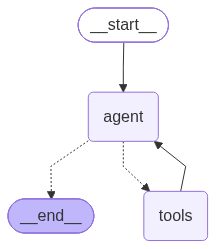

In [ ]:
if __name__ == "__main__":
    run_restaurant_sales_agent()

NameError: name 'agent_executor' is not defined